# 🏠 House Prices — Advanced Regression Techniques
## Exploratory Data Analysis

**Kaggle Competition** | [House Prices: Advanced Regression Techniques](https://www.kaggle.com/c/house-prices-advanced-regression-techniques)

---

### Notebook structure
1. Dataset overview
2. Target variable analysis (`SalePrice`)
3. Missing values analysis
4. Numerical features analysis
5. Categorical features analysis
6. Correlation analysis
7. Feature engineering insights
8. Key takeaways

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data.data_loader import load_data, train_path, test_path
from src.utils.utils import missing_summary
from scipy import stats
from scipy.stats import skew, kurtosis

plt.style.use('seaborn-v0_8-whitegrid')

In [71]:
train = load_data(train_path).drop(columns=["Id"])
test = load_data(test_path).drop(columns=["Id"])

print(f"Train Shape: {train.shape}")
print(f"Test Shape: {test.shape}")
train.head()

Train Shape: (1460, 80)
Test Shape: (1459, 79)


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


---

## 1. Dataset Overview

NB: OverallQual and OverallCond are already encoded, thus numerical, I've decided to keep them numerical for this EDA, but also add them as categorical for categorical analysis

In [72]:
train["OverallQualStr"] = train["OverallQual"].astype(str)
train["OverallCondStr"] = train["OverallCond"].astype(str)

num_cols = train.select_dtypes(include=["int", "float"]).columns.to_list()
cat_cols = list(set(train.columns) - set(num_cols))
feature_num_cols = list(set(num_cols) - {"SalePrice"})

print(f"Numerical Features: {len(feature_num_cols) - 2}")
print(f"Categorical Features: {len(cat_cols)}")
print(f"Total Features : {train.shape[1] - 3}")
train.describe()

Numerical Features: 34
Categorical Features: 45
Total Features : 79


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


---

## 2. Target Variable - SalePrice

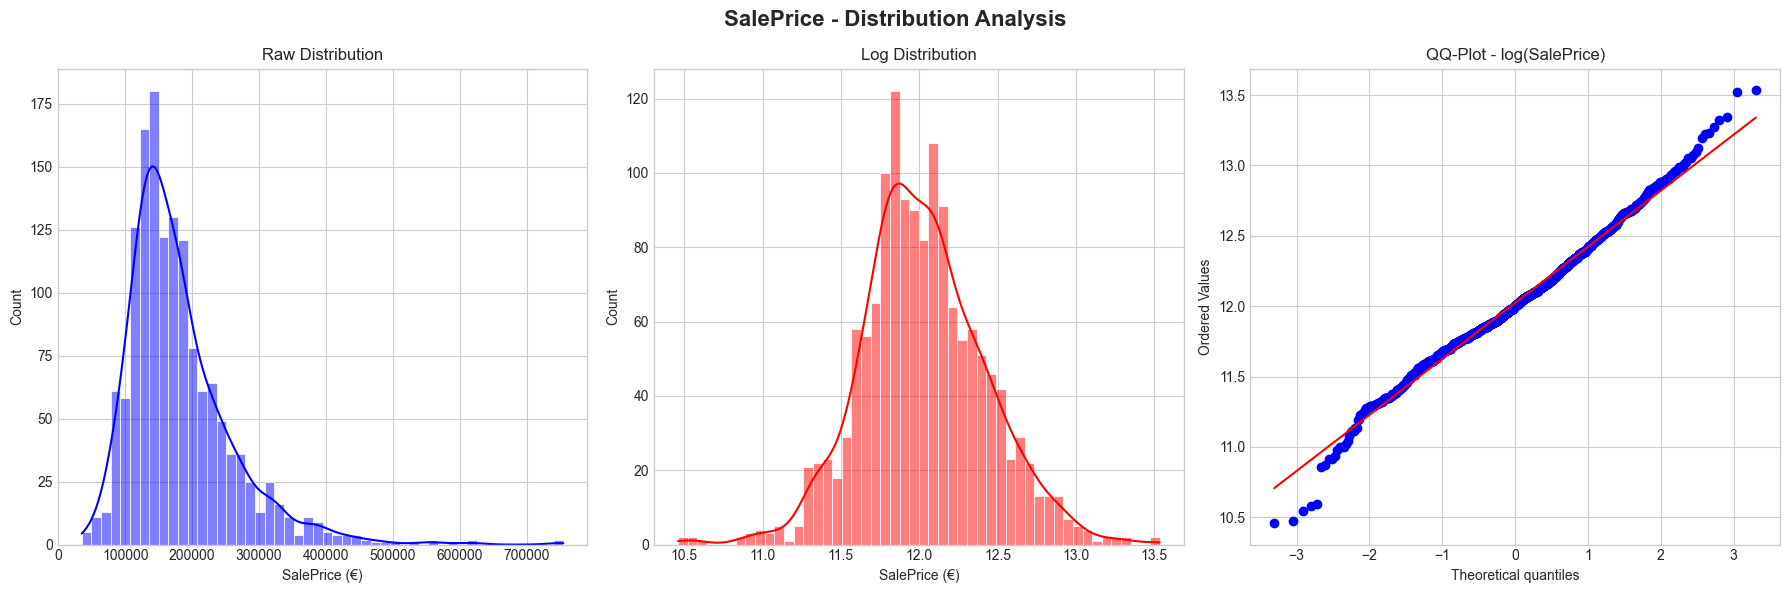

Mean        : $180,921
Median      : $163,000
Std         : $79,443
Skewness    : 1.881  (raw)
Skewness    : 0.121  (log-transformed)
Kurtosis    : 6.510


In [73]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))
fig.suptitle("SalePrice - Distribution Analysis", fontsize=16, fontweight="bold")

sns.histplot(data=train["SalePrice"],
             kde=True,
             color="b",
             bins=50,
             ax=axes[0])
axes[0].set_title("Raw Distribution")
axes[0].set_xlabel("SalePrice (€)")

sns.histplot(data=np.log1p(train["SalePrice"]),
             kde=True,
             color="r",
             bins=50,
             ax=axes[1])
axes[1].set_title("Log Distribution")
axes[1].set_xlabel("SalePrice (€)")

stats.probplot(np.log1p(train["SalePrice"]), plot=axes[2])
axes[2].set_title("QQ-Plot - log(SalePrice)")

plt.tight_layout()
plt.show()
print(f"Mean        : ${train['SalePrice'].mean():,.0f}")
print(f"Median      : ${train['SalePrice'].median():,.0f}")
print(f"Std         : ${train['SalePrice'].std():,.0f}")
print(f"Skewness    : {skew(train['SalePrice']):.3f}  (raw)")
print(f"Skewness    : {skew(np.log1p(train['SalePrice'])):.3f}  (log-transformed)")
print(f"Kurtosis    : {kurtosis(train['SalePrice']):.3f}")

`SalePrice` is right-skewed. Applying log1p brings the distribution closer to normal, which justifies the `TransformedTargetRegressor(func=np.log1p, inverse_func=np.expm1)` used in the pipeline.

---

## Missing Values Analysis

In [74]:
train_miss = missing_summary(train, "Train")
test_miss = missing_summary(test, "Test")

print(f'Train — columns with missing values: {len(train_miss)}')
print(f'Test  — columns with missing values: {len(test_miss)}')
train_miss

Train — columns with missing values: 19
Test  — columns with missing values: 33


,Missing,Missing (%)
Train — Column,,
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55


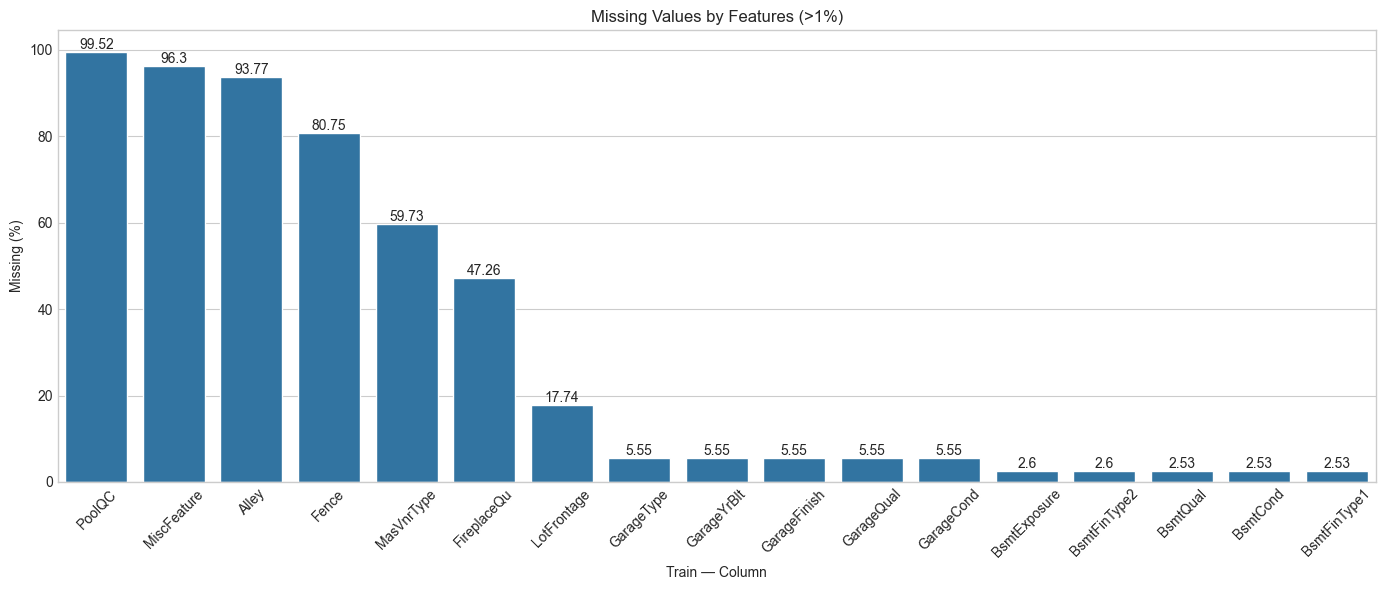

In [75]:
fig, ax = plt.subplots(figsize=(14, 6))
train_miss_top = train_miss.query("`Missing (%)` > 1")

sns.barplot(x=train_miss_top.index,
            y=train_miss_top["Missing (%)"],
            ax=ax)
ax.tick_params(axis='x', rotation=45)
ax.bar_label(ax.containers[0], fontsize=10)
ax.set_title("Missing Values by Features (>1%)")
plt.tight_layout()

Many missing values are meaningful (i.e `PoolQC` NaN = no pool, `Alley` NaN = no alley access)

---

## 4. Numerical Features Analysis

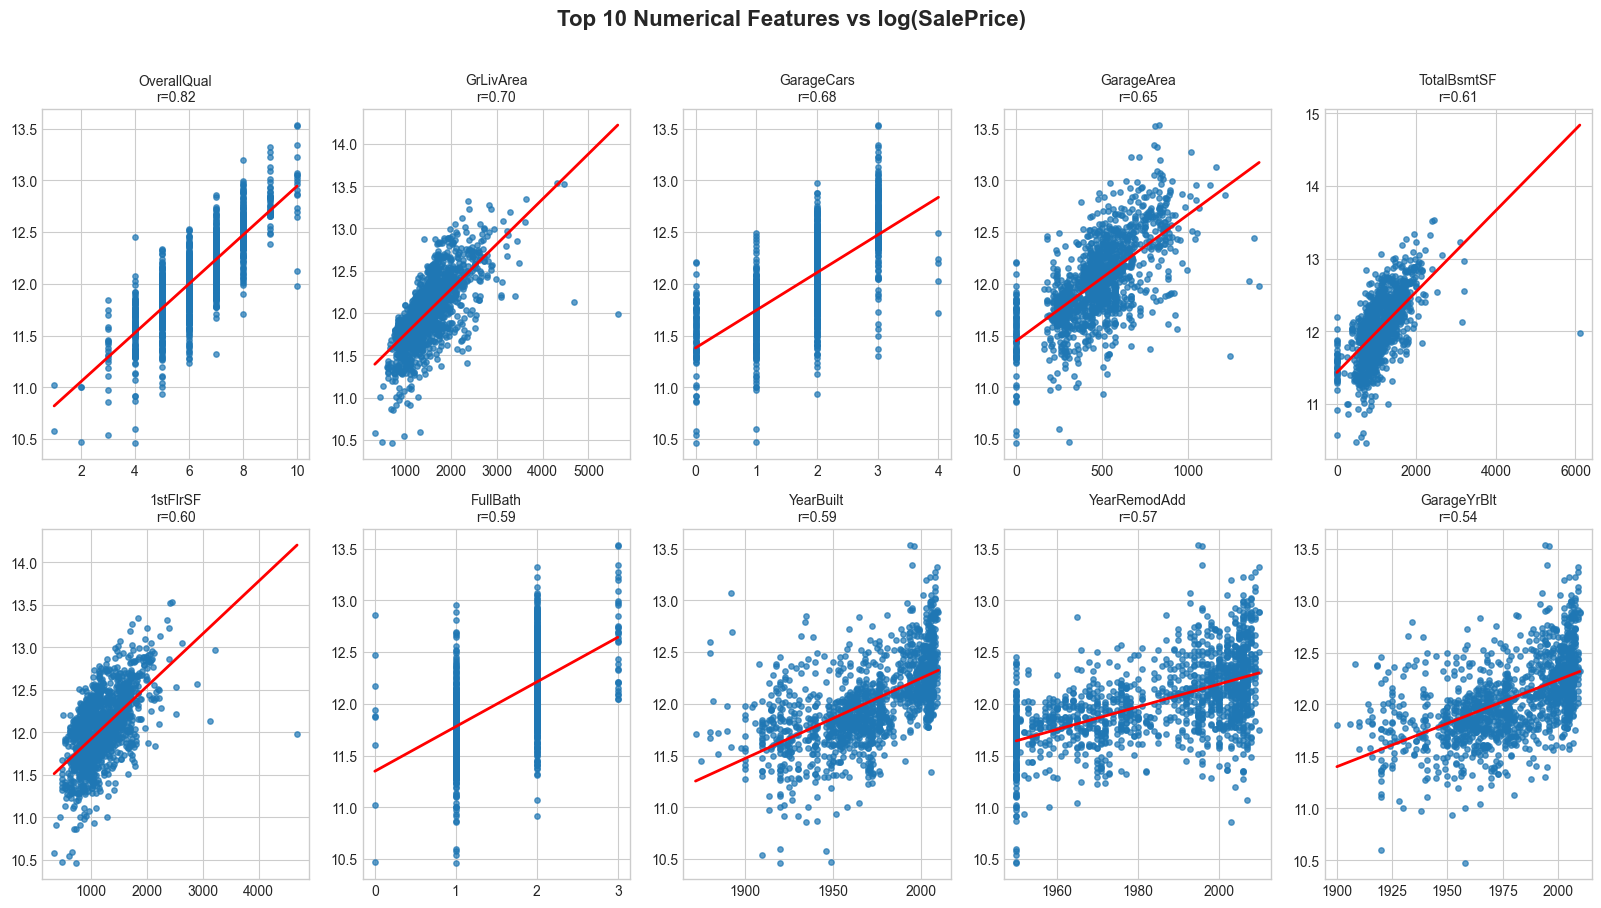

In [115]:
train["LogSalePrice"] = np.log1p(train["SalePrice"])

corr_with_target = (
    train[feature_num_cols]
    .corrwith(train["LogSalePrice"])
    .abs()
    .sort_values(ascending=False))

top10 = corr_with_target.head(10)

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 10))
fig.suptitle("Top 10 Numerical Features vs log(SalePrice)", fontsize=16, fontweight="bold")

for ax, feat in zip(axes.flatten(), top10.index):

    sns.regplot(
        data=train,
        x=feat,
        y="LogSalePrice",
        scatter_kws={"alpha":0.7, "s":15},
        line_kws={"color":"red", "lw":2},
        ci=None,
        ax=ax
    )
    ax.set_title(f"{feat}\nr={corr_with_target[feat]:.2f}", fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")



---

## 5. Categorical Features Analysis

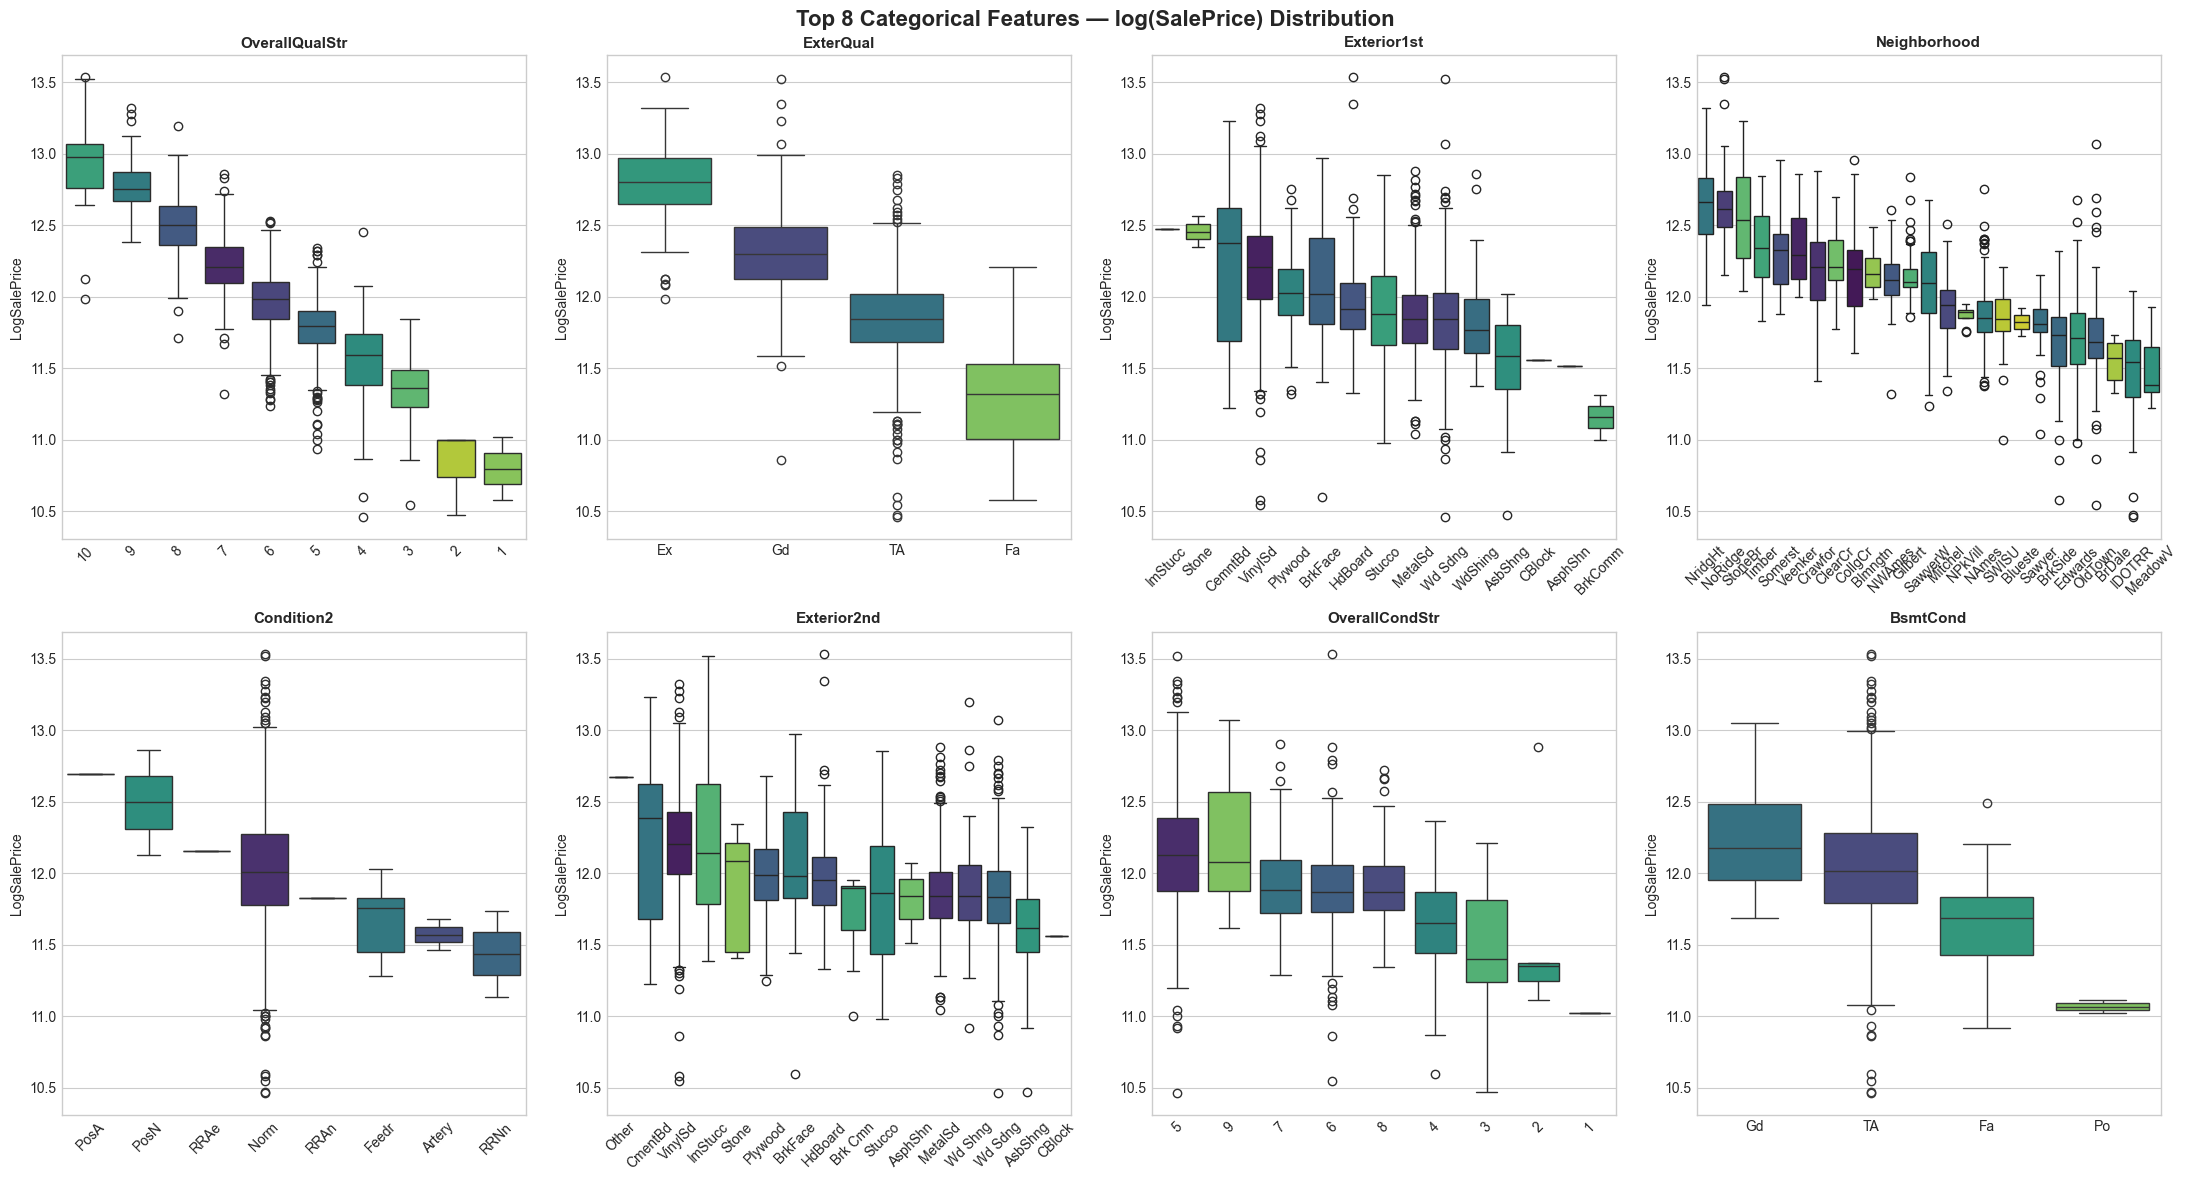

In [98]:
cat_variance = {}
for col in cat_cols:
    group_medians = train.groupby(col)["LogSalePrice"].median()
    cat_variance[col] = group_medians.max() - group_medians.min()

top_cats = pd.Series(cat_variance).sort_values(ascending=False).head(8)

fig, axes = plt.subplots(2, 4, figsize=(22, 12))
fig.suptitle("Top 8 Categorical Features — log(SalePrice) Distribution", fontsize=16, fontweight="bold")

for ax, feat in zip(axes.flatten(), top_cats.index):
    order = train.groupby(feat)["LogSalePrice"].median().sort_values(ascending=False).index

    sns.boxplot(
        data=train,
        x=feat,
        y="LogSalePrice",
        order=order,
        palette="viridis",
         hue=feat,
        legend=False,
        ax=ax)

    ax.set_title(feat, fontsize=11, fontweight="bold")
    ax.set_xlabel("")

    if train[feat].nunique() > 5:
        ax.tick_params(axis="x", rotation=45)

plt.tight_layout()

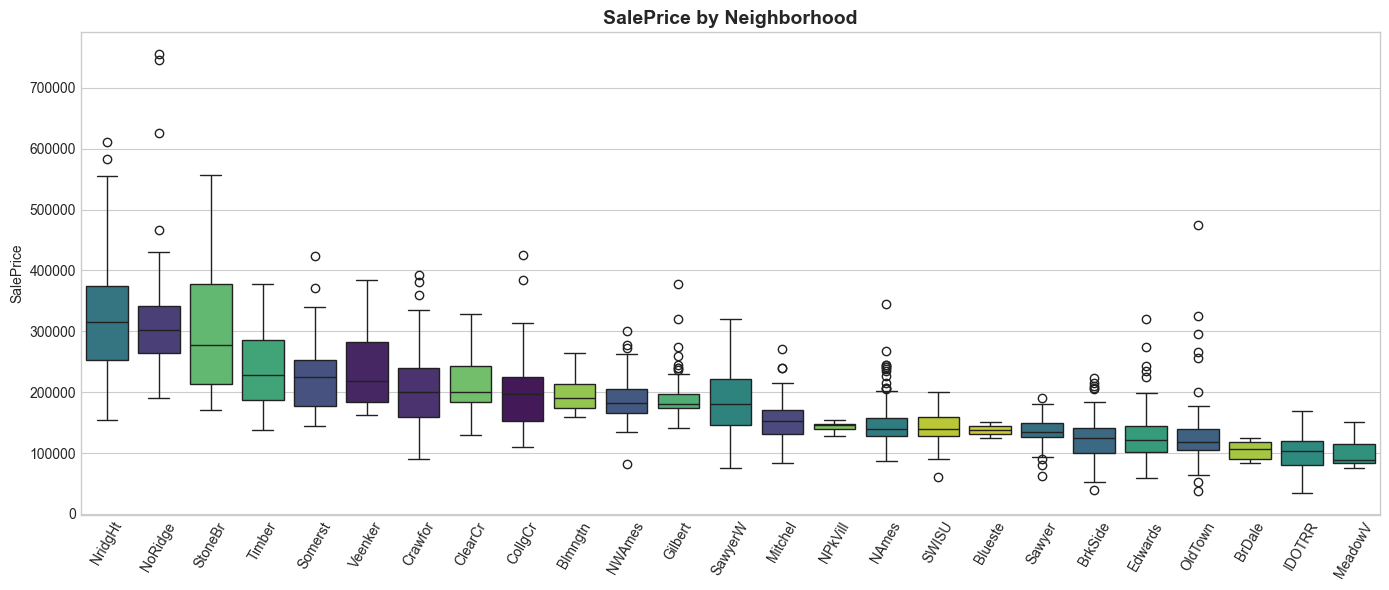

In [99]:
fig, ax = plt.subplots(figsize=(14, 6))
order = train.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).index
sns.boxplot(
    data=train,
    x='Neighborhood',
    y='SalePrice',
    order=order,
    palette="viridis",
    hue="Neighborhood",
    ax=ax)

ax.set_title('SalePrice by Neighborhood', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=60)
ax.set_xlabel('')
plt.tight_layout()

---

## 6. Correlation Analysis

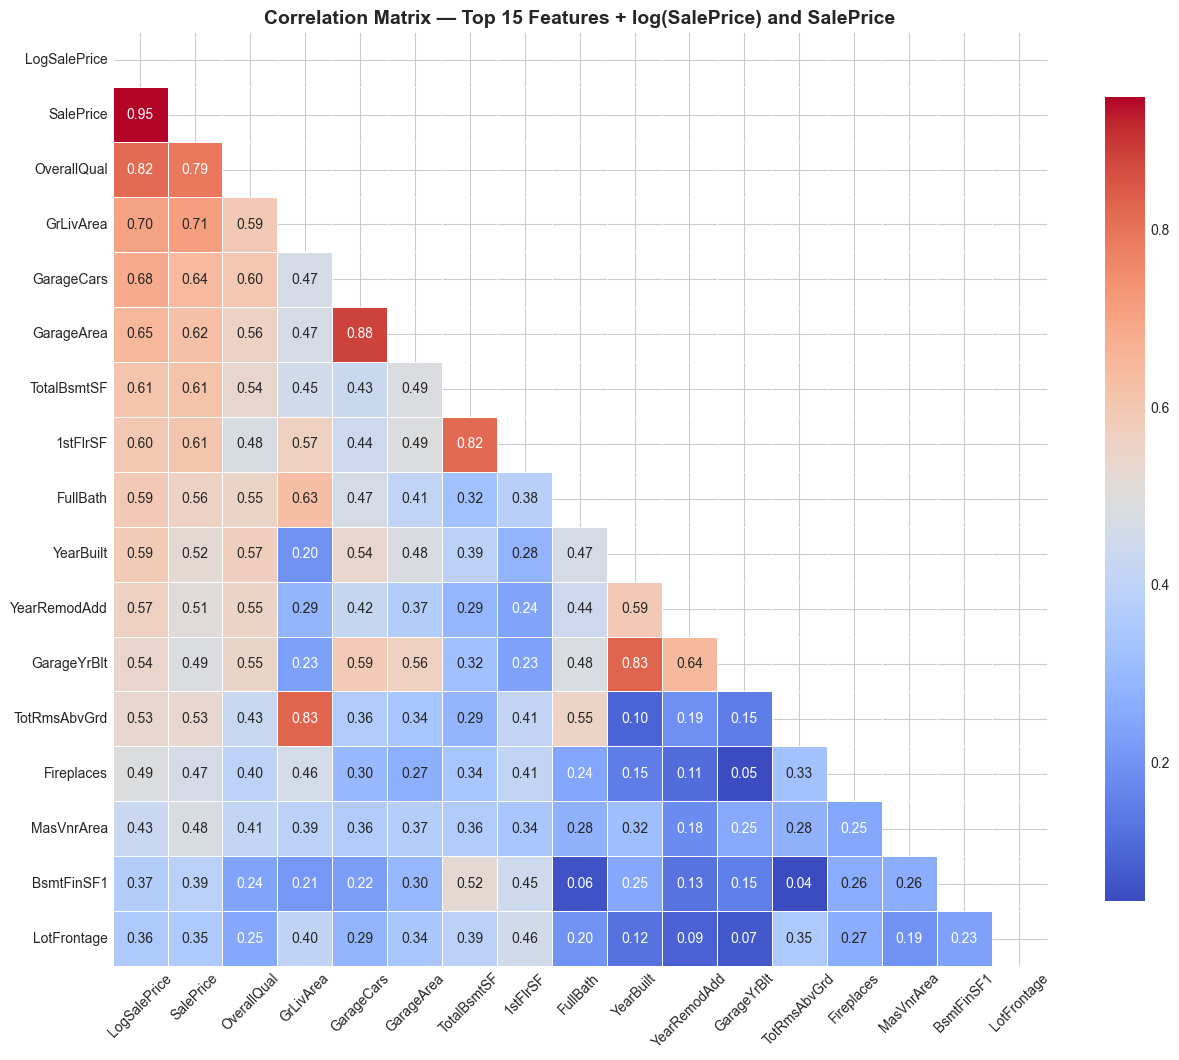

In [102]:
num_cols = train.select_dtypes(include=["int", "float"]).columns.to_list()
top15 = train[num_cols].corr()["LogSalePrice"].abs().sort_values(ascending=False).head(17).index
corrmat = train[top15].corr()

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corrmat, dtype=bool))
sns.heatmap(
    corrmat,
    mask=mask,
    annot=True, fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    ax=ax,
    square=True,
    cbar_kws={"shrink": 0.8}
)
ax.set_title("Correlation Matrix — Top 15 Features + log(SalePrice) and SalePrice", fontsize=14, fontweight='bold')
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()

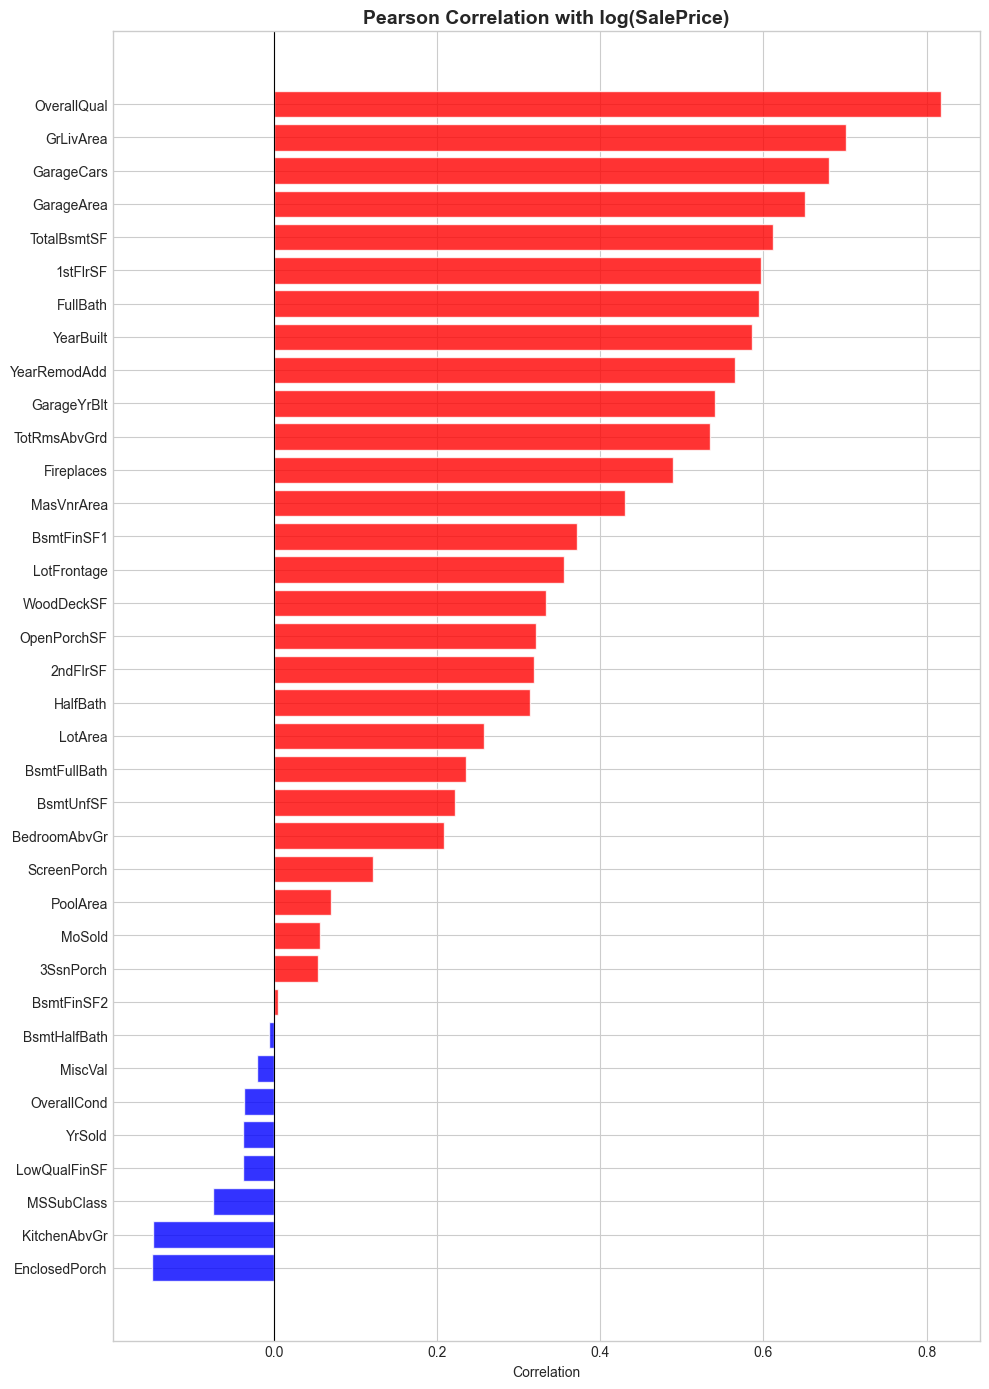

In [107]:
corr_target = train[num_cols].corr()["LogSalePrice"].drop(["LogSalePrice", "SalePrice"]).sort_values()

fig, ax = plt.subplots(figsize=(10, 14))
colors = ["red" if v > 0 else "blue" for v in corr_target.values]
ax.barh(corr_target.index, corr_target.values, color=colors, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson Correlation with log(SalePrice)', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation')
plt.tight_layout()

---

## 7. Feature Engineering Insights

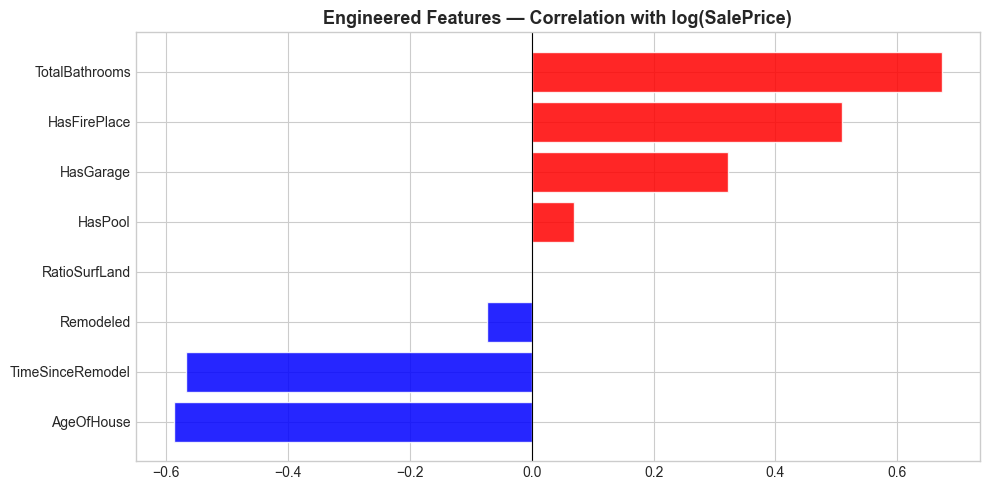

In [110]:
df = train.copy()


df["TotalBathrooms"] = df[["FullBath",'BsmtFullBath']].sum(axis=1) + 0.5 * df[["HalfBath","BsmtHalfBath"]].sum(axis=1)
# Age features
df["AgeOfHouse"] = df["YrSold"] - df["YearBuilt"]
df["TimeSinceRemodel"] = df["YrSold"] - df["YearRemodAdd"]
# Binary
df["HasPool"] = (df["PoolArea"] > 0).astype(int)
df["HasFirePlace"] = (df["Fireplaces"] > 0).astype(int)
df["HasGarage"] = (df["GarageCars"] > 0).astype(int)
df["Remodeled"] = (df["YearBuilt"] != df["YearRemodAdd"]).astype(int)
# Ratio
df["RatioSurfLand"] = df["GrLivArea"] / df["LotArea"]

new_features = ["TotalBathrooms", "AgeOfHouse", "TimeSinceRemodel", "HasPool",
                'HasFirePlace', "HasGarage", "Remodeled", "RatioSurfLand"]

corr_new = df[new_features + ["LogSalePrice"]].corr()["LogSalePrice"].drop("LogSalePrice").sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["red" if v > 0 else "blue" for v in corr_new.values]
ax.barh(corr_new.index, corr_new.values, color=colors, alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Engineered Features — Correlation with log(SalePrice)", fontsize=13, fontweight="bold")
plt.tight_layout()

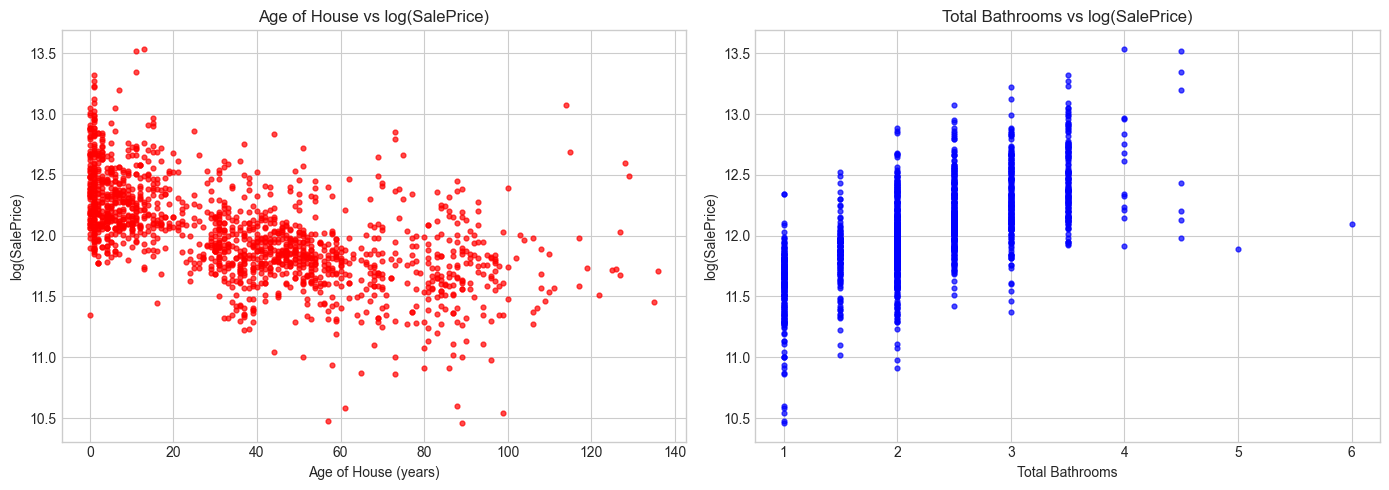

In [128]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df["AgeOfHouse"], df["LogSalePrice"], alpha=0.7, s=12, color="r")
axes[0].set_xlabel("Age of House (years)")
axes[0].set_ylabel("log(SalePrice)")
axes[0].set_title("Age of House vs log(SalePrice)")

axes[1].scatter(df["TotalBathrooms"], df["LogSalePrice"], alpha=0.7, s=12, color="blue")
axes[1].set_xlabel("Total Bathrooms")
axes[1].set_ylabel("log(SalePrice)")
axes[1].set_title("Total Bathrooms vs log(SalePrice)")

plt.tight_layout()

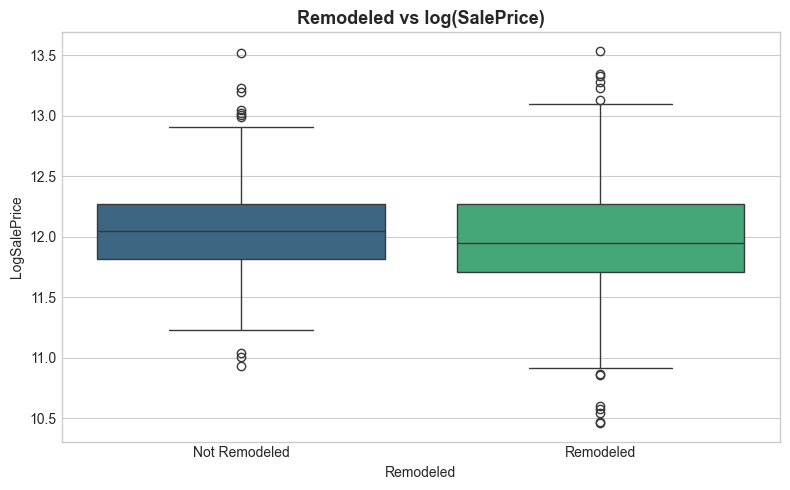

Median log(SalePrice) — Remodeled     : $11.95
Median log(SalePrice) — Not Remodeled : $12.04
Difference : +-0.8%


In [127]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df,
            x="Remodeled",
            y="LogSalePrice",
            palette="viridis",
            hue="Remodeled",
            legend=False,
            ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Not Remodeled", "Remodeled"])
ax.set_title("Remodeled vs log(SalePrice)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

r_med = df[df["Remodeled"]==1]["LogSalePrice"].median()
nr_med = df[df["Remodeled"]==0]["LogSalePrice"].median()
print(f"Median log(SalePrice) — Remodeled     : ${r_med:,.2f}")
print(f"Median log(SalePrice) — Not Remodeled : ${nr_med:,.2f}")
print(f"Difference : +{(r_med - nr_med) / nr_med * 100:.1f}%")

---
## 8. Key Takeaways

| Observation | Implication |
|---|---|
| `SalePrice` is right-skewed | → `log1p` transformation applied via `TransformedTargetRegressor` |
| Many NaNs are semantically meaningful | → `FillKnownNan` transformer handles structural NaNs |
| `LotFrontage` has 17% missing | → Imputed with grouped median by `MSZoning` × `LotArea` bin |
| Neighborhood creates strong price tiers | → Captured via OneHotEncoding |


### Modeling approach
A **Stacking Ensemble** was used combining:
- `ElasticNet` | `SVR` | `XGBoost` | `LightGBM` | `CatBoost` | `RandomForest`
- Meta-learner: `ElasticNet`
- Hyperparameters tuned with **Optuna** (300 trials per model, 5-fold CV, MAE objective)
- Optimized hyperparameters using MAE rather than RMSLE to reduce sensitivity to outliers during cross-validation.
- Target log-transformed via `TransformedTargetRegressor`